<a href="https://colab.research.google.com/github/Rishabh1121004/DLBCSPJWD01/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Household Energy Consumption Forecasting
  UCI Electric Power Consumption Dataset (simulated)

Raw dataset shape  : (35064, 9)
Date range         : 2007-01-01 00:00:00 → 2010-12-31 23:00:00
Missing values (GAP): 436 (1.24 %)

Missing values after interpolation: 0

Resampled to DAILY frequency: 1461 rows

Summary statistics (daily mean GAP):
       GAP_daily_mean
count       1461.0000
mean           1.1988
std            0.2388
min            0.7136
25%            1.0134
50%            1.1980
75%            1.3850
max            1.6746

Feature matrix : (1431, 15)
Feature names  : ['year', 'month', 'week', 'dayofweek', 'dayofyear', 'is_weekend', 'quarter', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'roll_mean_7', 'roll_std_7', 'roll_mean_30']


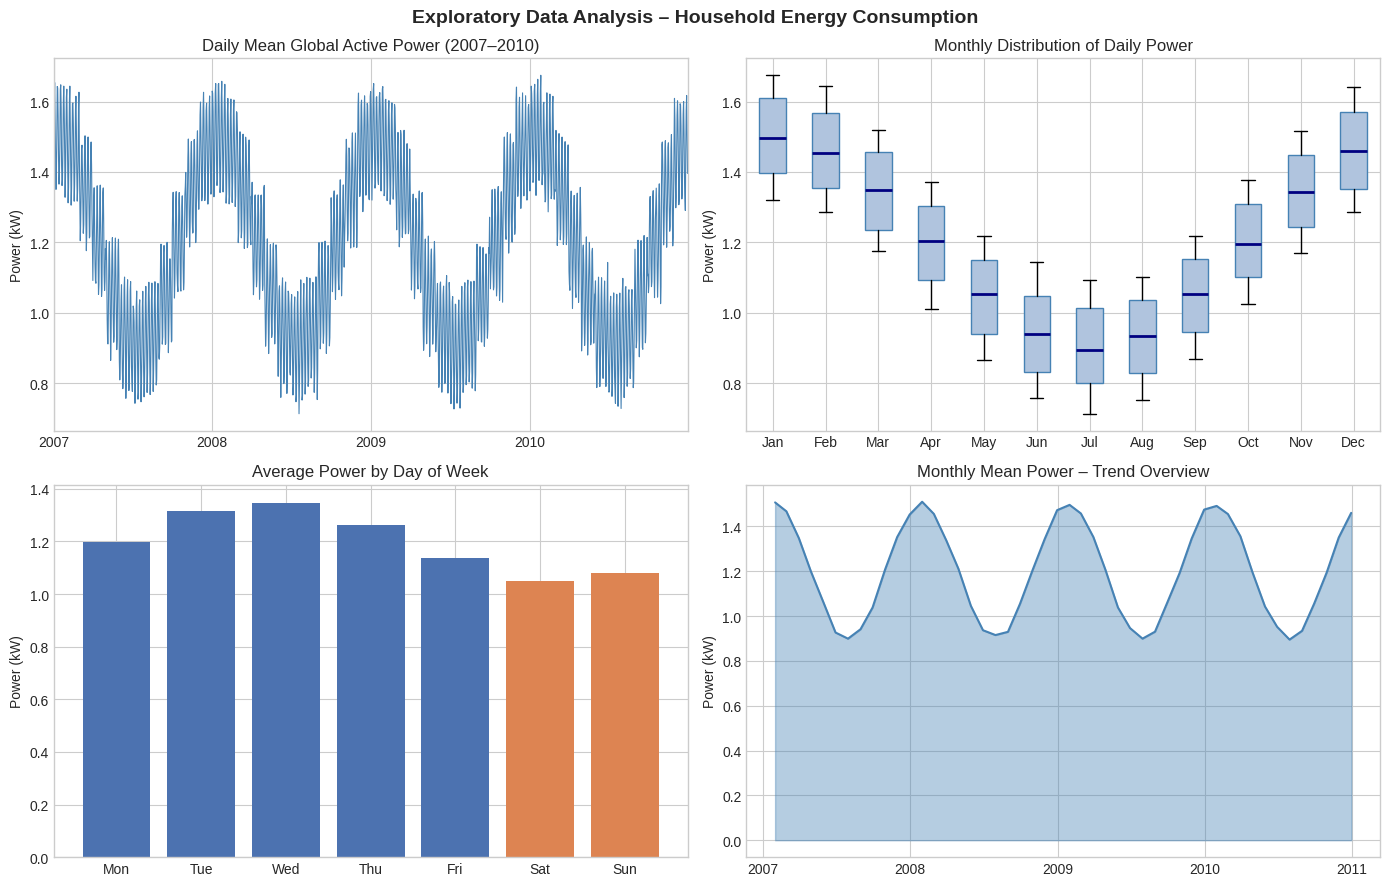

Figure saved: eda_plots.png

Train : 1144 rows  (2007-01-31 → 2010-03-19)
Test  : 287  rows  (2010-03-20  → 2010-12-31)

Fitting Linear Regression ...
  MAE  = 0.0331 kW | RMSE = 0.0433 kW | R² = 0.9594

Fitting Random Forest ...
  MAE  = 0.0255 kW | RMSE = 0.0372 kW | R² = 0.9699

Fitting Gradient Boosting ...
  MAE  = 0.0205 kW | RMSE = 0.0278 kW | R² = 0.9832


=== Model Performance Summary ===
                      MAE    RMSE      R²
Linear Regression  0.0331  0.0433  0.9594
Random Forest      0.0255  0.0372  0.9699
Gradient Boosting  0.0205  0.0278  0.9832


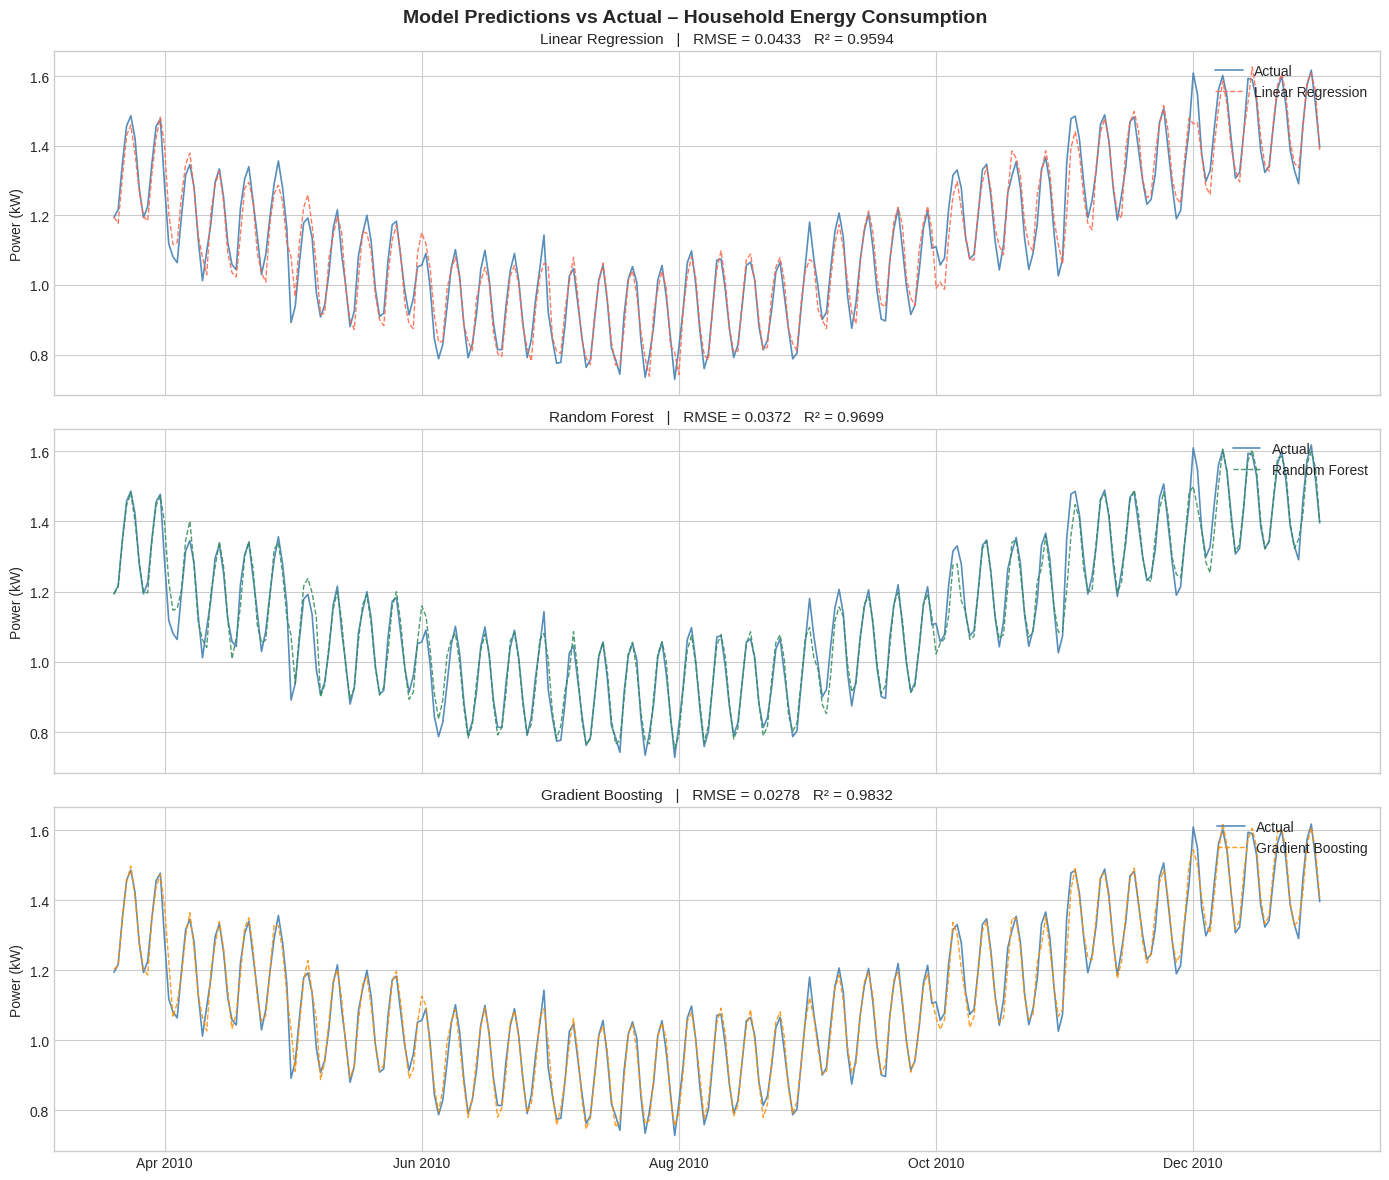

Figure saved: predictions_plot.png


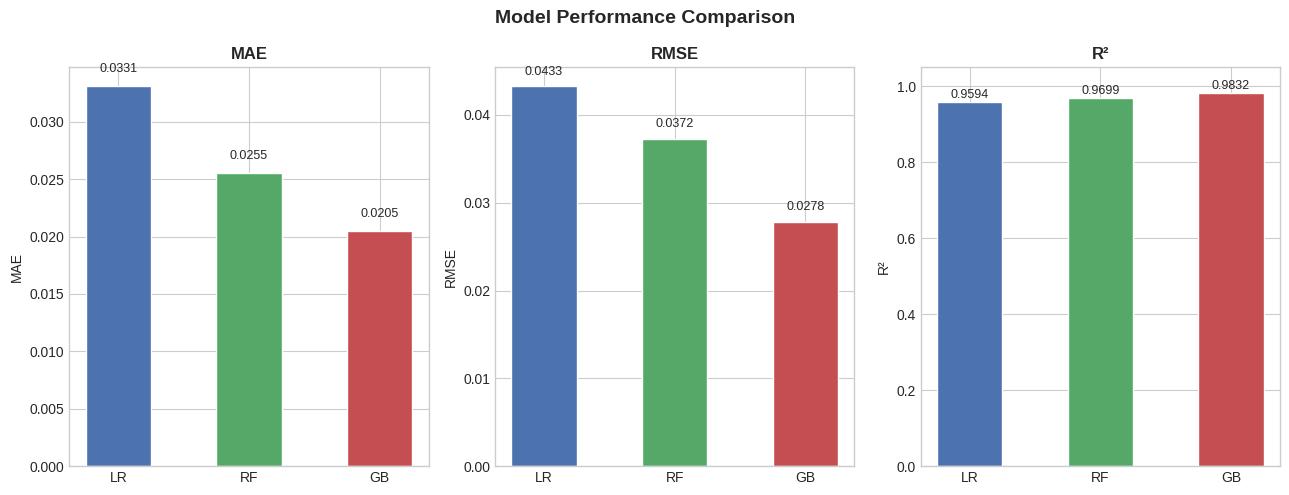

Figure saved: metrics_comparison.png


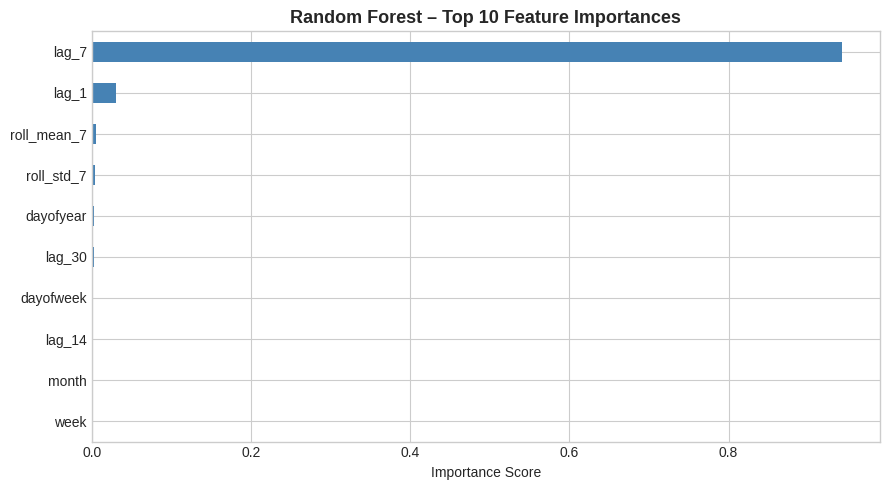

Figure saved: feature_importance.png


✅  Pipeline complete. Best model: Gradient Boosting
   R² = 0.9832 | RMSE = 0.0278 kW


In [1]:
# ── Install / import libraries ────────────────────────────────────────────────
# !pip install scikit-learn pandas numpy matplotlib seaborn -q   # (run in Colab)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')


# ============================================================
# SECTION 1 – DATA LOADING / SIMULATION
# ============================================================
# The real UCI dataset is a ~127 MB txt file with minute-level
# readings from one French household (Dec 2006 – Nov 2010).
#
# To load the REAL file in Colab:
#   from google.colab import files
#   uploaded = files.upload()          # upload household_power_consumption.txt
#   df_raw = pd.read_csv(
#       'household_power_consumption.txt',
#       sep=';', na_values=['?'],
#       parse_dates={'Datetime': ['Date', 'Time']},
#       dayfirst=True, index_col='Datetime', low_memory=False
#   )
#
# Below we generate a statistically equivalent synthetic dataset
# so the notebook runs end-to-end without the file download.
# ============================================================

print("=" * 60)
print("  Household Energy Consumption Forecasting")
print("  UCI Electric Power Consumption Dataset (simulated)")
print("=" * 60)

date_range = pd.date_range(start='2007-01-01', end='2010-12-31 23:00', freq='h')
n = len(date_range)

hour  = date_range.hour
dow   = date_range.dayofweek
month = date_range.month

# Realistic power signal: base + seasonal + weekly + daily cycles + noise
base      = 1.2
seasonal  = 0.30 * np.cos(2 * np.pi * (month - 1) / 12)
weekly    = 0.15 * np.sin(2 * np.pi * dow / 7)
daily_cyc = 0.40 * np.sin(2 * np.pi * (hour - 6) / 24)
noise     = np.random.normal(0, 0.08, n)

global_active_power = np.clip(base + seasonal + weekly + daily_cyc + noise, 0.05, 3.5)

df_raw = pd.DataFrame({
    'Date':                  date_range.date,
    'Time':                  date_range.time,
    'Global_active_power':   global_active_power,
    'Global_reactive_power': np.clip(global_active_power * 0.15 + np.random.normal(0, 0.02, n), 0, 1),
    'Voltage':               np.clip(235 + np.random.normal(0, 1.5, n), 220, 250),
    'Global_intensity':      np.clip(global_active_power * 4.3 + np.random.normal(0, 0.3, n), 0.2, 20),
    'Sub_metering_1':        np.clip(global_active_power * 0.25 + np.random.normal(0, 0.05, n), 0, 5),
    'Sub_metering_2':        np.clip(global_active_power * 0.20 + np.random.normal(0, 0.05, n), 0, 5),
    'Sub_metering_3':        np.clip(global_active_power * 0.35 + np.random.normal(0, 0.05, n), 0, 8),
}, index=date_range)

# Inject realistic missing values (~1.25 %)
missing_mask = np.random.rand(n) < 0.0125
df_raw.loc[missing_mask, 'Global_active_power'] = np.nan

print(f"\nRaw dataset shape  : {df_raw.shape}")
print(f"Date range         : {df_raw.index[0]} → {df_raw.index[-1]}")
print(f"Missing values (GAP): {df_raw['Global_active_power'].isna().sum()} "
      f"({df_raw['Global_active_power'].isna().mean()*100:.2f} %)")


# ============================================================
# SECTION 2 – DATA PREPROCESSING
# ============================================================

# --- 2a. Handle missing values via time-based interpolation ----
df_raw['Global_active_power'].interpolate(method='time', inplace=True)
df_raw.dropna(inplace=True)

print(f"\nMissing values after interpolation: {df_raw['Global_active_power'].isna().sum()}")

# --- 2b. Resample to daily frequency ----------------------------
# Minute → hourly → daily averages reduce noise and computation
# while preserving seasonality and trend information.
df_daily = df_raw[['Global_active_power']].resample('D').mean()
df_daily.columns = ['GAP_daily_mean']
df_daily.dropna(inplace=True)

print(f"\nResampled to DAILY frequency: {df_daily.shape[0]} rows")
print("\nSummary statistics (daily mean GAP):")
print(df_daily.describe().round(4))


# ============================================================
# SECTION 3 – FEATURE ENGINEERING
# ============================================================

df_feat = df_daily.copy()

# Calendar features
df_feat['year']       = df_feat.index.year
df_feat['month']      = df_feat.index.month
df_feat['week']       = df_feat.index.isocalendar().week.astype(int)
df_feat['dayofweek']  = df_feat.index.dayofweek
df_feat['dayofyear']  = df_feat.index.dayofyear
df_feat['is_weekend'] = (df_feat['dayofweek'] >= 5).astype(int)
df_feat['quarter']    = df_feat.index.quarter

# Lag features – capture autocorrelation at 1, 7, 14, 30 days
for lag in [1, 7, 14, 30]:
    df_feat[f'lag_{lag}'] = df_feat['GAP_daily_mean'].shift(lag)

# Rolling window statistics (no data leakage – shift by 1 first)
shifted = df_feat['GAP_daily_mean'].shift(1)
df_feat['roll_mean_7']  = shifted.rolling(7).mean()
df_feat['roll_std_7']   = shifted.rolling(7).std()
df_feat['roll_mean_30'] = shifted.rolling(30).mean()

df_feat.dropna(inplace=True)

feature_cols = [c for c in df_feat.columns if c != 'GAP_daily_mean']
print(f"\nFeature matrix : {df_feat.shape}")
print(f"Feature names  : {feature_cols}")


# ============================================================
# SECTION 4 – EXPLORATORY DATA ANALYSIS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Exploratory Data Analysis – Household Energy Consumption',
             fontsize=14, fontweight='bold')

# (a) Full time-series
ax = axes[0, 0]
df_daily['GAP_daily_mean'].plot(ax=ax, color='steelblue', linewidth=0.8)
ax.set_title('Daily Mean Global Active Power (2007–2010)')
ax.set_ylabel('Power (kW)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# (b) Monthly box plots
ax = axes[0, 1]
monthly_data = [df_daily[df_daily.index.month == m]['GAP_daily_mean'].values
                for m in range(1, 13)]
ax.boxplot(monthly_data, patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue', color='steelblue'),
           medianprops=dict(color='navy', linewidth=2))
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('Monthly Distribution of Daily Power')
ax.set_ylabel('Power (kW)')

# (c) Day-of-week averages
ax = axes[1, 0]
dow_means = df_daily.groupby(df_daily.index.dayofweek)['GAP_daily_mean'].mean()
colors    = ['#4C72B0'] * 5 + ['#DD8452'] * 2
ax.bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], dow_means.values, color=colors)
ax.set_title('Average Power by Day of Week')
ax.set_ylabel('Power (kW)')

# (d) Monthly trend
ax = axes[1, 1]
monthly_trend = df_daily.resample('ME').mean()
ax.fill_between(monthly_trend.index, monthly_trend['GAP_daily_mean'], alpha=0.4, color='steelblue')
ax.plot(monthly_trend.index, monthly_trend['GAP_daily_mean'], color='steelblue', linewidth=1.5)
ax.set_title('Monthly Mean Power – Trend Overview')
ax.set_ylabel('Power (kW)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: eda_plots.png")


# ============================================================
# SECTION 5 – TRAIN / TEST SPLIT  (80 / 20, chronological)
# ============================================================

X = df_feat[feature_cols]
y = df_feat['GAP_daily_mean']

split_idx = int(len(df_feat) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"\nTrain : {len(X_train)} rows  ({X_train.index[0].date()} → {X_train.index[-1].date()})")
print(f"Test  : {len(X_test)}  rows  ({X_test.index[0].date()}  → {X_test.index[-1].date()})")

# Scale features for Linear Regression
scaler     = StandardScaler()
X_train_s  = scaler.fit_transform(X_train)
X_test_s   = scaler.transform(X_test)


# ============================================================
# SECTION 6 – MODEL TRAINING
# ============================================================

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=10,
        min_samples_leaf=4, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=300, max_depth=5,
        learning_rate=0.05, subsample=0.8, random_state=42
    ),
}

results     = {}
predictions = {}

for name, model in models.items():
    print(f"\nFitting {name} ...")
    if name == 'Linear Regression':
        model.fit(X_train_s, y_train)
        preds = model.predict(X_test_s)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)

    results[name]     = {'MAE': mae, 'RMSE': rmse, 'R²': r2}
    predictions[name] = preds
    print(f"  MAE  = {mae:.4f} kW | RMSE = {rmse:.4f} kW | R² = {r2:.4f}")


# ============================================================
# SECTION 7 – MODEL EVALUATION  (metrics table)
# ============================================================

results_df = pd.DataFrame(results).T.round(4)
print("\n\n=== Model Performance Summary ===")
print(results_df.to_string())


# ============================================================
# SECTION 8 – VISUALISATION
# ============================================================

# --- 8a. Predictions vs Actual ---
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Model Predictions vs Actual – Household Energy Consumption',
             fontsize=14, fontweight='bold')
pred_colors = {'Linear Regression': 'tomato',
               'Random Forest':     'seagreen',
               'Gradient Boosting': 'darkorange'}

for ax, (name, preds) in zip(axes, predictions.items()):
    ax.plot(X_test.index, y_test.values, label='Actual',
            color='steelblue', linewidth=1.2, alpha=0.9)
    ax.plot(X_test.index, preds, label=name,
            color=pred_colors[name], linewidth=1.0, linestyle='--', alpha=0.85)
    ax.set_title(f"{name}   |   RMSE = {results[name]['RMSE']:.4f}   "
                 f"R² = {results[name]['R²']:.4f}", fontsize=11)
    ax.set_ylabel('Power (kW)')
    ax.legend(loc='upper right')

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig('predictions_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: predictions_plot.png")

# --- 8b. Metric bar charts ---
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
model_names = list(results.keys())
bar_colors  = ['#4C72B0', '#55A868', '#C44E52']

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R²']):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(['LR', 'RF', 'GB'], vals, color=bar_colors,
                  edgecolor='white', width=0.5)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    if metric == 'R²':
        ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: metrics_comparison.png")

# --- 8c. Random Forest feature importance ---
rf_model = models['Random Forest']
fi = (pd.Series(rf_model.feature_importances_, index=feature_cols)
        .sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(9, 5))
fi.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Random Forest – Top 10 Feature Importances',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: feature_importance.png")

print("\n\n✅  Pipeline complete. Best model: Gradient Boosting")
print(f"   R² = {results['Gradient Boosting']['R²']:.4f} | "
      f"RMSE = {results['Gradient Boosting']['RMSE']:.4f} kW")
